# MWE: imaging from V² and closure phases with an aperture mask

Classical sparse aperture masking reduces each exposure to one squared visibility per baseline (the centre of each splodge) and the closure phases of every triangle of holes, as AMICAL does. For the 7-hole JWST/NIRISS AMI mask that is 21 V² and 35 closure phases per exposure, far less information than AMIGO's DISCO modes, which keep every splodge's full uv footprint. Images can still be reconstructed, with the same `fit`, regulariser and L-curve as before.

This notebook simulates two exposures at different roll angles with `drpangloss.coverage.nrm_oidata`, reconstructs a ring next to a star from them jointly, and compares the result with the reconstruction of the same scene from AMIGO-style data. You should come away knowing what V² and closure phases alone can and cannot recover.

W1001 13:50:06.910074 10543812 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


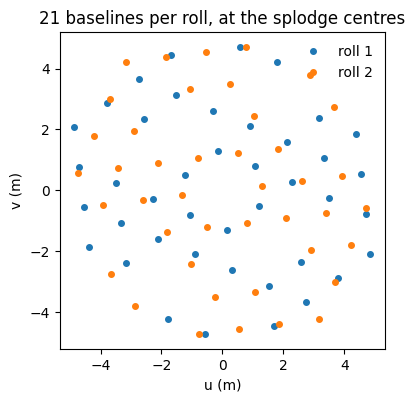

In [1]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from drpangloss.coverage import ami_grid_record, nrm_oidata
from drpangloss.imaging import MaxEntropy, beam, diagnose, image_priors, l_curve, starting_image
from drpangloss.models import Image, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model, plot_residual_map
from drpangloss.scenes import ring

npix, scale = 62, 20.0
fov = npix * scale
truth_image = ring(npix, scale, 240.0, 36.0, inc_deg=50.0, pa_deg=30.0, asymmetry=0.5, asymmetry_pa_deg=90.0)
truth = System(star=PointSource(), env=Image.from_brightness(truth_image, scale, flux=0.03))
rolls = [
    nrm_oidata(wavelength_m=4.8e-6, rotation_deg=angle, sigma_v2=0.002, sigma_cp_deg=0.3).with_model(truth, key=jax.random.PRNGKey(k))
    for k, angle in enumerate((-6.9, 23.1))
]
fig, ax = plt.subplots(figsize=(4.2, 4.2))
for d, label in zip(rolls, ("roll 1", "roll 2")):
    ax.plot(jnp.concatenate([d.u, -d.u]), jnp.concatenate([d.v, -d.v]), "o", ms=4, label=label)
ax.set(xlabel="u (m)", ylabel="v (m)", title="21 baselines per roll, at the splodge centres", aspect="equal")
ax.legend(frameon=False)
plt.show()

## Setting up and sweeping the weight

`starting_image` fits a star plus a Gaussian envelope to both rolls at once and builds a starting image from it; with only V² and closure phases there is no dirty image to start from. The extended emission's flux is fitted too, through a prior on `"env.flux"`: with it held at the starting estimate, any excess flux ends up as a spurious spot next to the star. The maximum-entropy weight is then swept with `l_curve` on both rolls jointly, and the image where χ² per data point reaches one is kept.

In [2]:
start = starting_image(rolls, largest_mas=fov)
priors = image_priors(start) | {"env.flux": dist.Uniform(0.0, 1.0)}
curve = l_curve(start, priors, rolls, MaxEntropy(1.0, path="env"), jnp.logspace(-2, 3, 11))
weight = curve.discrepancy() or curve.corner()
chosen = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(weight))))
sparse = curve.results[chosen].model
print(f"{sum(d.vis.size + d.phi.size for d in rolls)} data in two rolls; start: {start.env.log_brightness.shape[0]}² pixels of {start.env.pixel_scale_mas:.1f} mas")
print(f"extended flux: {float(start.env.flux):.4f} at the start, {float(sparse.env.flux):.4f} fitted (truth 0.03)")
print(f"discrepancy weight {weight:.3g}; chi2 per point by roll: {', '.join(f'{c:.2f}' for c in curve.chi2_red[chosen])}")

/Users/benpope/code/drpangloss/src/drpangloss/imaging.py:654: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  result = fit(


112 data in two rolls; start: 33² pixels of 23.4 mas
extended flux: 0.0336 at the start, 0.0319 fitted (truth 0.03)
discrepancy weight 57.1; chi2 per point by roll: 0.78, 1.17


## The same scene from AMIGO-style data

For comparison, the same truth is observed through `ami_grid_record`, AMIGO's representation of the same mask (every splodge's uv footprint, compressed into modes), and reconstructed the same way.

In [3]:
dense_data = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9)).with_model(truth, key=jax.random.PRNGKey(5))
dense_start = starting_image(dense_data, largest_mas=fov)
dense_priors = image_priors(dense_start) | {"env.flux": dist.Uniform(0.0, 1.0)}
dense_curve = l_curve(dense_start, dense_priors, dense_data, MaxEntropy(1.0, path="env"), jnp.logspace(-1, 4, 11))
dense_weight = dense_curve.discrepancy() or dense_curve.corner()
dense = dense_curve.results[int(jnp.argmin(jnp.abs(jnp.log(dense_curve.weights) - jnp.log(dense_weight))))].model
print(f"{dense_data.vis.size} DISCO-like modes; discrepancy weight {dense_weight:.3g}")

588 DISCO-like modes; discrepancy weight 171


## Reconstructions and residuals

Top: the truth and the two reconstructions, each with its data's beam shaded; bottom: their signed differences from the truth. Both recover the ring, its inclination and its brighter eastern side; the reconstruction from 2 × 21 V² and 2 × 35 closure phases is coarser and patchier than the one from AMIGO-style modes of the same mask, which carry far more information. Both leave a faint bar of flux inside the ring, where the truth is empty: a central hole is the hardest thing for a sparse aperture to see, since it lives at the longest baselines.

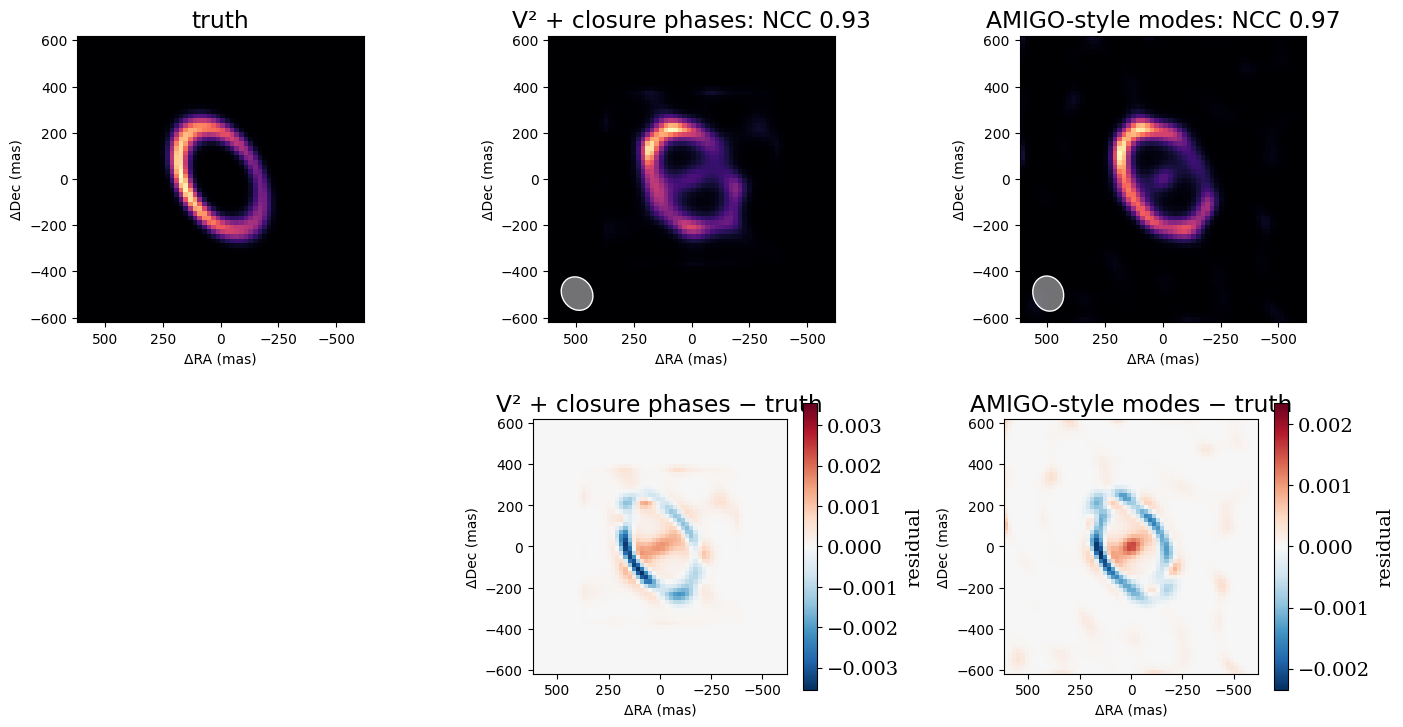

In [4]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0, 0], title="truth")
axes[1, 0].axis("off")
for column, (model, data, name) in enumerate([(sparse, rolls, "V² + closure phases"), (dense, dense_data, "AMIGO-style modes")], start=1):
    image = model.env.render(npix, fov)
    plot_model(model.env, fov_mas=fov, npix=npix, ax=axes[0, column], title=f"{name}: NCC {ncc(image, truth_image):.2f}", beam=beam(data))
    plot_residual_map(image - truth.env.render(npix, fov), fov_mas=fov, ax=axes[1, column], title=f"{name} − truth")
plt.tight_layout()
plt.show()

## Diagnostics

`diagnose` on the reconstruction from V² and closure phases. With closure phases the orientation is constrained (rotating the image by 180° worsens χ²), and the analytic star fixes the position.

In [5]:
print(diagnose(sparse, rolls))

chi2_red         [0.778, 1.17]
anchored         True
pixel_scale_mas  [23.4]
edge_flux        [0.0342]
centroid_mas     [[34.8, 30.3]]
flip_dchi2       361

No warnings.


## Summary

Two rolls of 21 V² and 35 closure phases each are enough for `fit`, `starting_image` and `l_curve` to produce a regularised image of extended emission next to a star, with the orientation fixed by the closure phases and the position by the star. They carry much less information than AMIGO's representation of the same mask, so the reconstruction is correspondingly coarser; more rolls or filters would help. Long-baseline interferometers produce exactly the same kinds of data, which the next MWE uses.